# Q3. Feature Engineering and Regression Pipeline

Build a reproducible scikit-learn regression pipeline to predict `items_sold` at a retail store.

**Dataset:** 1200 rows × 9 columns. Date range: 2022-01-01 to 2024-12-31. No missing values.

**Columns:** `transaction_date`, `store_id`, `store_size`, `location_type`, `promotion_type`, `is_weekend`, `is_festival`, `competition_density`, `items_sold`

## 1. Date Feature Engineering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/q3_retail_promotions.csv')
print('Shape:', df.shape)
print('Columns:', list(df.columns))
print('Missing values:', df.isnull().sum().sum())
print('\nFirst 5 rows:')
display(df.head())

Shape: (1200, 9)
Columns: ['transaction_date', 'store_id', 'store_size', 'location_type', 'promotion_type', 'is_weekend', 'is_festival', 'competition_density', 'items_sold']
Missing values: 0

First 5 rows:


,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277


In [2]:
# Parse transaction_date and extract features
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

df['year']        = df['transaction_date'].dt.year
df['month']       = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek   # 0=Monday, 6=Sunday
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

print('New columns extracted from transaction_date:')
print('  year, month, day_of_week, is_month_end')
print(f'\nis_month_end distribution (1 = day >= 25):')
print(df['is_month_end'].value_counts().sort_index())

print('\nSample of resulting dataframe with new columns:')
display(df[['transaction_date','year','month','day_of_week','is_month_end','items_sold']].head(10))

New columns extracted from transaction_date:
  year, month, day_of_week, is_month_end

is_month_end distribution (1 = day >= 25):
is_month_end
0    959
1    241
Name: count, dtype: int64

Sample of resulting dataframe with new columns:


,transaction_date,year,month,day_of_week,is_month_end,items_sold
0,2022-01-01,2022,1,5,0,224
1,2022-01-01,2022,1,5,0,348
2,2022-01-02,2022,1,6,0,249
3,2022-01-02,2022,1,6,0,259
4,2022-01-03,2022,1,0,0,277
5,2022-01-03,2022,1,0,0,411
6,2022-01-04,2022,1,1,0,193
7,2022-01-04,2022,1,1,0,240
8,2022-01-05,2022,1,2,0,305
9,2022-01-05,2022,1,2,0,181


## 2. Temporal Train-Test Split

In [3]:
# Sort by date and use most recent 20% as test set
df = df.sort_values('transaction_date').reset_index(drop=True)

split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx].copy()
test_df  = df.iloc[split_idx:].copy()

print(f'Total records : {len(df)}')
print(f'Training set  : {len(train_df)} rows  |  '
      f'{train_df["transaction_date"].min().date()} to {train_df["transaction_date"].max().date()}')
print(f'Test set      : {len(test_df)} rows  |  '
      f'{test_df["transaction_date"].min().date()} to {test_df["transaction_date"].max().date()}')

Total records : 1200
Training set  : 960 rows  |  2022-01-01 to 2024-06-11
Test set      : 240 rows  |  2024-06-12 to 2024-12-31


**Why a random split is inappropriate for time-ordered data:**

This dataset spans 3 years (2022–2024). A **random split** would mix future records into the training set and past records into the test set — this is **data leakage**. The model would be trained on information that came *after* some test records, making its performance appear unrealistically good. It doesn't simulate how the model will be used in production, where it must always predict future events using only past data.

A **temporal split** — training on the oldest 80% (Jan 2022 – Jun 2024) and testing on the most recent 20% (Jun–Dec 2024) — faithfully replicates the real-world scenario: forecasting future store sales using historical patterns. This gives an honest, unbiased estimate of out-of-sample performance.

## 3. Preprocessing Pipeline

In [4]:
# Define feature groups
categorical_features = ['promotion_type', 'location_type', 'store_size']
numerical_features   = ['year', 'month', 'day_of_week', 'is_month_end',
                         'is_weekend', 'is_festival', 'competition_density']
target = 'items_sold'

X_train = train_df[categorical_features + numerical_features]
y_train = train_df[target]
X_test  = test_df[categorical_features + numerical_features]
y_test  = test_df[target]

# ColumnTransformer: OHE for categoricals, StandardScaler for numerics
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
    ('num', StandardScaler(), numerical_features)
])

print('Preprocessing pipeline (ColumnTransformer):')
print(f'  OneHotEncoder  → {categorical_features}')
print(f'  StandardScaler → {numerical_features}')
print(f'\nTraining X shape: {X_train.shape}, Test X shape: {X_test.shape}')

Preprocessing pipeline (ColumnTransformer):
  OneHotEncoder  → ['promotion_type', 'location_type', 'store_size']
  StandardScaler → ['year', 'month', 'day_of_week', 'is_month_end', 'is_weekend', 'is_festival', 'competition_density']

Training X shape: (960, 10), Test X shape: (240, 10)


## 4. Model Training and Evaluation

In [5]:
# Build and train both pipelines — fit ONLY on training set
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)
print('Both pipelines fitted on training set only.')

Both pipelines fitted on training set only.


In [6]:
# Generate predictions and compute RMSE and MAE
y_pred_lr = lr_pipeline.predict(X_test)
y_pred_rf = rf_pipeline.predict(X_test)

def report_metrics(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    print(f'{name}:')
    print(f'  RMSE : {rmse:.4f}  (avg error in items, penalises large errors more)')
    print(f'  MAE  : {mae:.4f}  (avg absolute error in items)')
    return rmse, mae

print('=== Test Set Performance ===')
lr_rmse, lr_mae = report_metrics('Linear Regression', y_test, y_pred_lr)
print()
rf_rmse, rf_mae = report_metrics('Random Forest Regressor', y_test, y_pred_rf)

print(f'\nRandom Forest improvement over Linear Regression:')
print(f'  ΔRMSE: {lr_rmse - rf_rmse:+.4f} (positive = RF worse on RMSE for this dataset)')
print(f'  ΔMAE:  {lr_mae  - rf_mae:+.4f}')

=== Test Set Performance ===
Linear Regression:
  RMSE : 27.1252  (avg error in items, penalises large errors more)
  MAE  : 21.0715  (avg absolute error in items)

Random Forest Regressor:
  RMSE : 31.1882  (avg error in items, penalises large errors more)
  MAE  : 25.0342  (avg absolute error in items)

Random Forest improvement over Linear Regression:
  ΔRMSE: -4.0630 (positive = RF worse on RMSE for this dataset)
  ΔMAE:  -3.9628


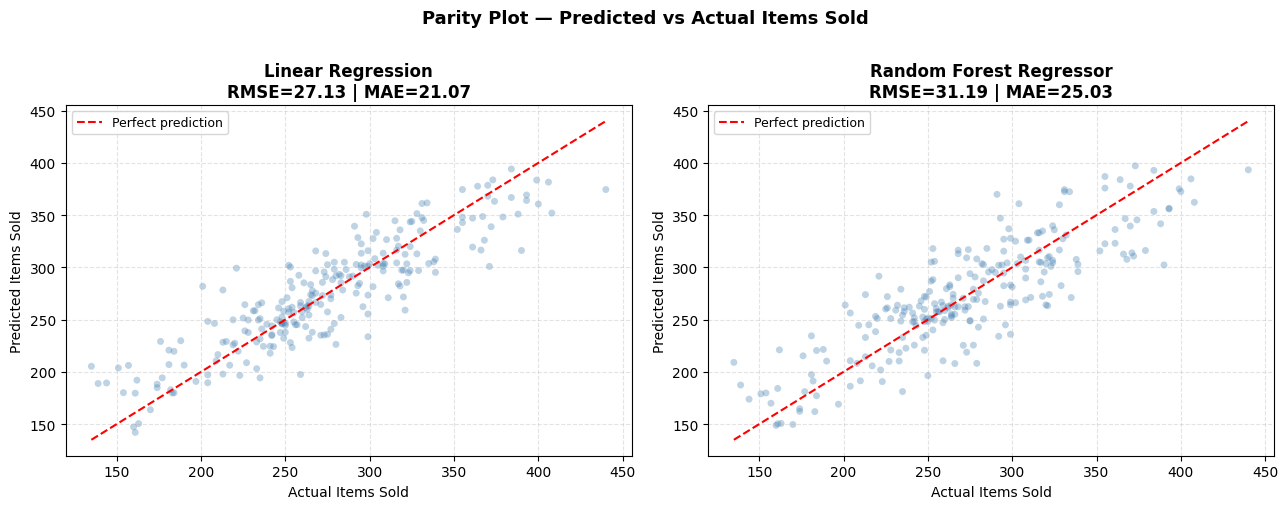

In [7]:
# Parity plots: Predicted vs Actual for both models
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, name, y_pred, rmse, mae in zip(
    axes,
    ['Linear Regression', 'Random Forest Regressor'],
    [y_pred_lr, y_pred_rf],
    [lr_rmse, rf_rmse],
    [lr_mae, rf_mae]
):
    ax.scatter(y_test, y_pred, alpha=0.35, s=25, color='steelblue', edgecolors='none')
    mn = min(y_test.min(), y_pred.min())
    mx = max(y_test.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect prediction')
    ax.set_title(f'{name}\nRMSE={rmse:.2f} | MAE={mae:.2f}', fontweight='bold')
    ax.set_xlabel('Actual Items Sold')
    ax.set_ylabel('Predicted Items Sold')
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.35)

plt.suptitle('Parity Plot — Predicted vs Actual Items Sold', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Top 5 Most Influential Features (Random Forest):


,feature,importance
0,is_festival,0.173610
1,store_size_small,0.165463
2,location_type_urban,0.107645
3,day_of_week,0.085597
4,is_weekend,0.069095


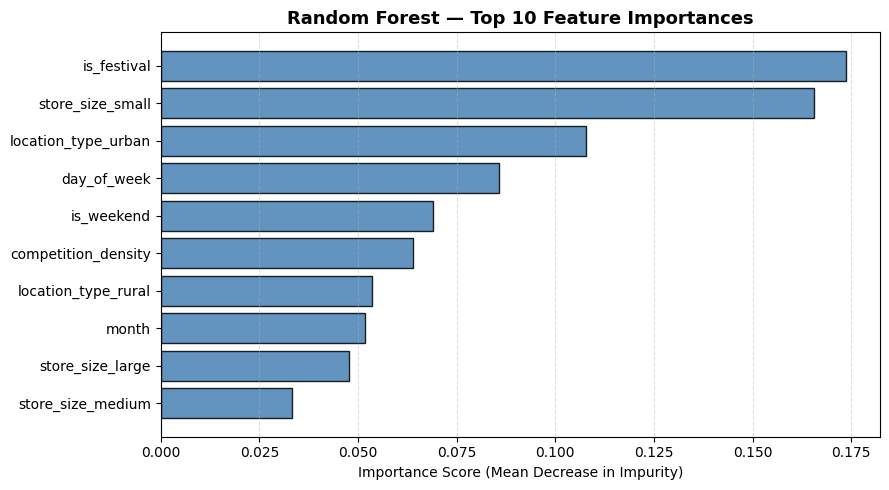

In [8]:
# Feature importances from Random Forest
rf_model = rf_pipeline.named_steps['model']
ohe = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat']
ohe_feature_names = ohe.get_feature_names_out(categorical_features).tolist()
all_features = ohe_feature_names + numerical_features

importance_df = pd.DataFrame({
    'feature':    all_features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print('Top 5 Most Influential Features (Random Forest):')
display(importance_df.head(5))

# Bar chart of top 10
top10 = importance_df.head(10)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top10['feature'][::-1], top10['importance'][::-1],
        color='steelblue', edgecolor='black', alpha=0.85)
ax.set_title('Random Forest — Top 10 Feature Importances', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score (Mean Decrease in Impurity)')
ax.grid(True, axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()